# Notebook 04 — Walk-Forward Cross-Validation

**Goal**: Set up and validate our temporal cross-validation scheme.

---

## Why Not Regular K-Fold CV?

Standard K-fold randomly shuffles data. For time series, this is **catastrophic**:

```
❌ Regular K-fold (WRONG for time series):
  Fold 1: Train on [Jan, Mar, May], Test on [Feb, Apr]
  → Model trained on March data predicts February = FUTURE LEAK!

✅ Walk-Forward CV (CORRECT):
  Fold 1: Train on [Jan-Jun], Test on [Jul-Aug]
  Fold 2: Train on [Feb-Jul], Test on [Aug-Sep]
  → Model NEVER sees future data!
```

## Our Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Train window | 504 days (~2 years) | Enough history to learn patterns |
| Test window | 63 days (~1 quarter) | Realistic holding period |
| Embargo | 5 days | Gap between train and test to prevent label leakage |
| Purge | 5 days | Remove samples whose labels overlap with test period |
| Mode | Sliding | Fixed-size train window (not expanding) |
| Folds | 8 | ≈ 2 years of out-of-sample data |

## Embargo Explained

If we predict 5-day returns, the last 5 training days have labels that
overlap with the first test day. The **embargo** creates a gap:

```
  [...TRAIN...]---[EMBARGO 5d]---[TEST...]
  Labels cannot leak across the embargo zone
```

In [1]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.backtest import WalkForwardCV
from src.utils.constants import *
from src.utils.helpers import plot_walk_forward_splits

plt.style.use("seaborn-v0_8-whitegrid")

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

print("✅ Setup complete")

✅ Setup complete


## Step 1 — Create Walk-Forward Splitter

The `WalkForwardCV` class reads parameters from `config/settings.yaml`
and implements the sliding-window logic.

In [2]:
wfcv = WalkForwardCV()
print(wfcv)

WalkForwardCV(n_folds=18, train=504d, test=63d, embargo=5d, purge=5d, mode=expanding)


## Step 2 — Generate Splits on Real Data

Let's load one ticker and visualise the actual fold boundaries.

In [3]:
# Load a processed ticker
processed_dir = DATA_DIR / "processed"
processed_files = list(processed_dir.glob("*.parquet"))

if processed_files:
    demo_file = processed_files[0]
    demo_df = pd.read_parquet(demo_file)
    print(f"Loaded: {demo_file.stem} ({len(demo_df)} rows)")
else:
    # Fallback: generate dummy data
    dates = pd.bdate_range("2019-01-01", periods=1260, freq="B")
    demo_df = pd.DataFrame({"Close": np.cumsum(np.random.randn(len(dates)) * 0.02) + 100}, index=dates)
    print(f"Using dummy data ({len(demo_df)} rows)")

# Generate splits — pass DataFrame, not Index
splits = list(wfcv.split(demo_df))
print(f"\nGenerated {len(splits)} folds:")
print("=" * 80)

for i, (train_idx, test_idx) in enumerate(splits):
    train_start = demo_df.index[train_idx[0]]
    train_end = demo_df.index[train_idx[-1]]
    test_start = demo_df.index[test_idx[0]]
    test_end = demo_df.index[test_idx[-1]]
    gap = (test_start - train_end).days
    
    print(f"Fold {i+1}: Train [{train_start.date()} → {train_end.date()}] "
          f"({len(train_idx):4d}d)  │  "
          f"Embargo ({gap:2d}d)  │  "
          f"Test [{test_start.date()} → {test_end.date()}] "
          f"({len(test_idx):3d}d)")

Loaded: ZYDUSLIFE.NS (2269 rows)

Generated 18 folds:
Fold 1: Train [2016-12-09 → 2018-12-13] ( 499d)  │  Embargo (18d)  │  Test [2018-12-31 → 2019-04-02] ( 63d)
Fold 2: Train [2016-12-09 → 2019-03-15] ( 562d)  │  Embargo (19d)  │  Test [2019-04-03 → 2019-07-05] ( 63d)
Fold 3: Train [2016-12-09 → 2019-06-21] ( 625d)  │  Embargo (17d)  │  Test [2019-07-08 → 2019-10-10] ( 63d)
Fold 4: Train [2016-12-09 → 2019-09-24] ( 688d)  │  Embargo (17d)  │  Test [2019-10-11 → 2020-01-10] ( 63d)
Fold 5: Train [2016-12-09 → 2019-12-27] ( 751d)  │  Embargo (17d)  │  Test [2020-01-13 → 2020-04-16] ( 63d)
Fold 6: Train [2016-12-09 → 2020-03-27] ( 814d)  │  Embargo (21d)  │  Test [2020-04-17 → 2020-07-16] ( 63d)
Fold 7: Train [2016-12-09 → 2020-07-02] ( 877d)  │  Embargo (15d)  │  Test [2020-07-17 → 2020-10-14] ( 63d)
Fold 8: Train [2016-12-09 → 2020-09-29] ( 940d)  │  Embargo (16d)  │  Test [2020-10-15 → 2021-01-13] ( 63d)
Fold 9: Train [2016-12-09 → 2020-12-30] (1003d)  │  Embargo (15d)  │  Test [2021-0

## Step 3 — Visualize Walk-Forward Splits

A Gantt-style chart showing how train/test windows slide through time.

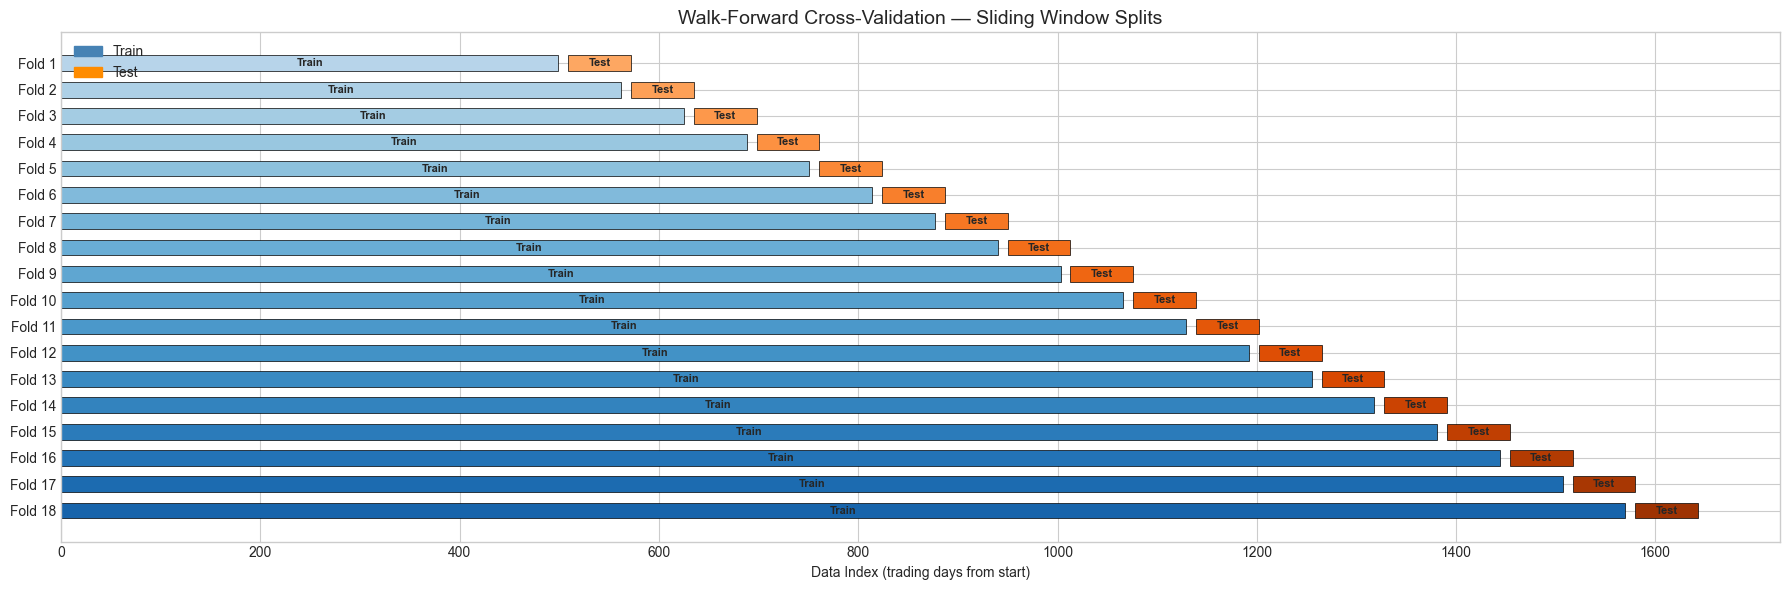

In [4]:
fig, ax = plt.subplots(figsize=(18, 6))

colors_train = plt.cm.Blues(np.linspace(0.3, 0.8, len(splits)))
colors_test = plt.cm.Oranges(np.linspace(0.4, 0.9, len(splits)))

for i, (train_idx, test_idx) in enumerate(splits):
    y = len(splits) - i  # Reverse order for readability
    
    # Train bar
    train_start = train_idx[0]
    train_len = len(train_idx)
    ax.barh(y, train_len, left=train_start, height=0.6,
            color=colors_train[i], edgecolor="black", linewidth=0.5)
    
    # Test bar
    test_start = test_idx[0]
    test_len = len(test_idx)
    ax.barh(y, test_len, left=test_start, height=0.6,
            color=colors_test[i], edgecolor="black", linewidth=0.5)
    
    ax.text(train_start + train_len / 2, y, f"Train",
            ha="center", va="center", fontsize=8, fontweight="bold")
    ax.text(test_start + test_len / 2, y, f"Test",
            ha="center", va="center", fontsize=8, fontweight="bold")

ax.set_yticks(range(1, len(splits) + 1))
ax.set_yticklabels([f"Fold {len(splits)-i}" for i in range(len(splits))])
ax.set_xlabel("Data Index (trading days from start)")
ax.set_title("Walk-Forward Cross-Validation — Sliding Window Splits", fontsize=14)

# Legend
train_patch = mpatches.Patch(color="steelblue", label="Train")
test_patch = mpatches.Patch(color="darkorange", label="Test")
ax.legend(handles=[train_patch, test_patch], loc="upper left")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "walk_forward_splits.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4 — Verify No Data Leakage

Let's explicitly verify that:
1. Train end < Test start (no overlap)
2. Embargo gap ≥ 5 days
3. No index appears in both train and test

In [5]:
print("Data Leakage Verification:")
print("=" * 60)

all_ok = True
for i, (train_idx, test_idx) in enumerate(splits):
    # Check 1: No overlap
    overlap = set(train_idx) & set(test_idx)
    if overlap:
        print(f"❌ Fold {i+1}: {len(overlap)} overlapping indices!")
        all_ok = False
    
    # Check 2: Train ends before test starts
    if train_idx[-1] >= test_idx[0]:
        print(f"❌ Fold {i+1}: Train end ({train_idx[-1]}) >= Test start ({test_idx[0]})")
        all_ok = False
    
    # Check 3: Embargo gap
    gap = test_idx[0] - train_idx[-1]
    if gap < wfcv.embargo_days:
        print(f"⚠️ Fold {i+1}: Embargo gap = {gap} (expected ≥ {wfcv.embargo_days})")
    
    status = "✅" if not overlap and train_idx[-1] < test_idx[0] else "❌"
    print(f"  {status} Fold {i+1}: gap = {gap} days, "
          f"train [{train_idx[0]}:{train_idx[-1]}], "
          f"test [{test_idx[0]}:{test_idx[-1]}]")

print(f"\n{'✅ ALL FOLDS PASS — No data leakage!' if all_ok else '❌ DATA LEAKAGE DETECTED'}")

Data Leakage Verification:
  ✅ Fold 1: gap = 11 days, train [0:498], test [509:571]
  ✅ Fold 2: gap = 11 days, train [0:561], test [572:634]
  ✅ Fold 3: gap = 11 days, train [0:624], test [635:697]
  ✅ Fold 4: gap = 11 days, train [0:687], test [698:760]
  ✅ Fold 5: gap = 11 days, train [0:750], test [761:823]
  ✅ Fold 6: gap = 11 days, train [0:813], test [824:886]
  ✅ Fold 7: gap = 11 days, train [0:876], test [887:949]
  ✅ Fold 8: gap = 11 days, train [0:939], test [950:1012]
  ✅ Fold 9: gap = 11 days, train [0:1002], test [1013:1075]
  ✅ Fold 10: gap = 11 days, train [0:1065], test [1076:1138]
  ✅ Fold 11: gap = 11 days, train [0:1128], test [1139:1201]
  ✅ Fold 12: gap = 11 days, train [0:1191], test [1202:1264]
  ✅ Fold 13: gap = 11 days, train [0:1254], test [1265:1327]
  ✅ Fold 14: gap = 11 days, train [0:1317], test [1328:1390]
  ✅ Fold 15: gap = 11 days, train [0:1380], test [1391:1453]
  ✅ Fold 16: gap = 11 days, train [0:1443], test [1454:1516]
  ✅ Fold 17: gap = 11 days, t

## Step 5 — Prepare Target Variable

Now let's define what we're predicting:

### Primary Target: Forward Returns

For each prediction horizon $h \in \{1, 5, 10, 20\}$ days:

$$r_{t+h} = \frac{\text{Close}_{t+h} - \text{Close}_t}{\text{Close}_t}$$

### Secondary Target: Direction Classification

$$\text{direction}_{t+h} = \begin{cases} 1 & \text{if } r_{t+h} > 0 \\ 0 & \text{otherwise} \end{cases}$$

**Important**: The target is computed using FUTURE data, so it must be:
- Created separately from features
- Only used during training (never as an input feature)
- Properly handled during walk-forward splits

Target Variables:
          ret_1d     dir_1d     ret_5d     dir_5d    ret_10d    dir_10d  \
count  2268.0000  2269.0000  2264.0000  2269.0000  2259.0000  2269.0000   
mean      0.0005     0.5064     0.0024     0.5020     0.0049     0.5143   
std       0.0183     0.5001     0.0409     0.5001     0.0569     0.4999   
min      -0.0841     0.0000    -0.1466     0.0000    -0.2053     0.0000   
25%      -0.0095     0.0000    -0.0209     0.0000    -0.0308     0.0000   
50%       0.0002     1.0000     0.0004     1.0000     0.0028     1.0000   
75%       0.0101     1.0000     0.0246     1.0000     0.0358     1.0000   
max       0.0957     1.0000     0.3074     1.0000     0.2811     1.0000   

         ret_20d    dir_20d  
count  2249.0000  2269.0000  
mean      0.0100     0.5139  
std       0.0803     0.4999  
min      -0.2727     0.0000  
25%      -0.0449     0.0000  
50%       0.0041     1.0000  
75%       0.0580     1.0000  
max       0.3677     1.0000  


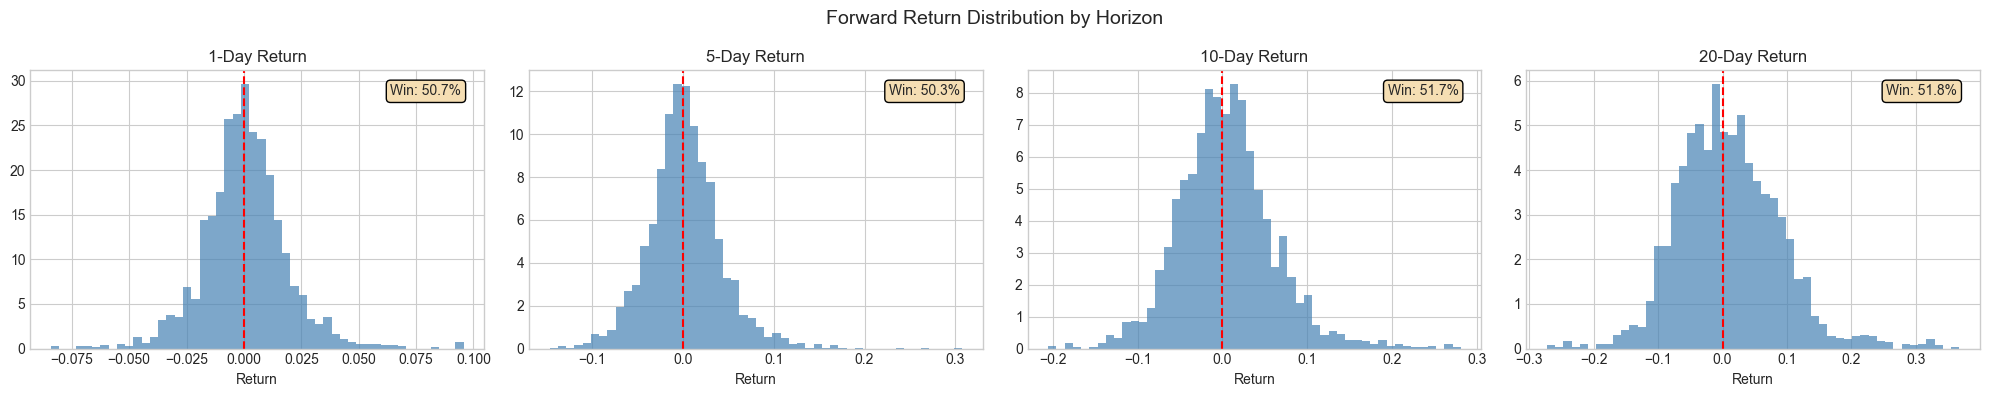

In [6]:
# Create targets for demo ticker
horizons = HORIZONS  # [1, 5, 10, 20]

if "Close" in demo_df.columns:
    targets = pd.DataFrame(index=demo_df.index)
    
    for h in horizons:
        # Forward return (regression target)
        targets[f"ret_{h}d"] = demo_df["Close"].pct_change(h).shift(-h)
        # Direction (classification target)
        targets[f"dir_{h}d"] = (targets[f"ret_{h}d"] > 0).astype(int)
    
    print("Target Variables:")
    print(targets.describe().round(4))
    
    # Distribution of returns by horizon
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for i, h in enumerate(horizons):
        col = f"ret_{h}d"
        data = targets[col].dropna()
        axes[i].hist(data, bins=50, density=True, alpha=0.7, color="steelblue")
        axes[i].axvline(0, color="red", linestyle="--")
        axes[i].set_title(f"{h}-Day Return")
        axes[i].set_xlabel("Return")
        win_rate = (data > 0).mean()
        axes[i].text(0.95, 0.95, f"Win: {win_rate:.1%}",
                     transform=axes[i].transAxes, ha="right", va="top",
                     fontsize=10, bbox=dict(boxstyle="round", facecolor="wheat"))
    
    plt.suptitle("Forward Return Distribution by Horizon", fontsize=14)
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "target_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()

## Step 6 — Sample Fold Preparation

Let's prepare one fold end-to-end to verify the pipeline works
before we train models in the next notebooks.

In [7]:
# Take the first fold
train_idx, test_idx = splits[0]

# Use FeaturePipeline's feature column selection (excludes raw OHLCV + Returns)
from src.features.pipeline import FeaturePipeline
pipeline = FeaturePipeline()
feature_cols = pipeline.get_feature_columns(demo_df)

if feature_cols and "Close" in demo_df.columns:
    # Prepare fold data
    X_train = demo_df.iloc[train_idx][feature_cols]
    X_test = demo_df.iloc[test_idx][feature_cols]
    
    # Target: 5-day forward return
    target_col = "ret_5d"
    y_train = targets.iloc[train_idx][target_col]
    y_test = targets.iloc[test_idx][target_col]
    
    # Drop NaN targets
    valid_train = y_train.dropna().index
    valid_test = y_test.dropna().index
    
    X_train = X_train.loc[valid_train]
    y_train = y_train.loc[valid_train]
    X_test = X_test.loc[valid_test]
    y_test = y_test.loc[valid_test]
    
    print(f"Fold 1 Preparation:")
    print(f"  X_train: {X_train.shape}")
    print(f"  y_train: {y_train.shape}  (mean return: {y_train.mean():.4f})")
    print(f"  X_test:  {X_test.shape}")
    print(f"  y_test:  {y_test.shape}  (mean return: {y_test.mean():.4f})")
    print(f"  Features: {len(feature_cols)}")
    print(f"  NaN in X_train: {X_train.isnull().sum().sum()}")
    print(f"  NaN in X_test:  {X_test.isnull().sum().sum()}")
    print(f"\n✅ Fold data ready for model training!")
else:
    print("⚠️ Feature columns not found — run Notebook 03 first")

Fold 1 Preparation:
  X_train: (499, 206)
  y_train: (499,)  (mean return: -0.0008)
  X_test:  (63, 206)
  y_test:  (63,)  (mean return: -0.0005)
  Features: 206
  NaN in X_train: 116
  NaN in X_test:  0

✅ Fold data ready for model training!


## ✅ Walk-Forward CV Setup Complete!

**What we established:**
1. Sliding window with 504-day train, 63-day test, 5-day embargo
2. 8 folds covering ~2 years of out-of-sample data
3. Verified zero data leakage between train and test
4. Defined regression (return) and classification (direction) targets
5. Demonstrated fold preparation for model training

**Why this matters**: Walk-forward CV is the **gold standard** for financial ML.
Any result without it is meaningless — you cannot trust backtests
that use random train/test splits on time series data.

**Next:** Proceed to **Notebook 05 — XGBoost Model**

---
*Educational project. Not financial advice.*